## Блок 1 - Установка библиотек

Блок проверяет наличие необходимых Python-библиотек (tensorflow, matplotlib, seaborn, opencv-python, scikit-learn, pandas, numpy) и устанавливает отсутствующие через pip. Это стандартная процедура для обеспечения воспроизводимости кода

In [1]:
import sys
import subprocess
import pkg_resources

required_packages = [
    'tensorflow',
    'matplotlib',
    'seaborn',
    'opencv-python',
    'scikit-learn',
    'pandas',
    'numpy'
]

to_install = []

for package in required_packages:
    try:
        pkg_resources.get_distribution(package)
    except pkg_resources.DistributionNotFound:
        to_install.append(package)

if to_install:
    print("Устанавливаю отсутствующие библиотеки:", to_install)
    for package in to_install:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    print("Готово.")
else:
    print("Все библиотеки уже установлены.")

Все библиотеки уже установлены.


При первом запуске устанавливаются недостающие библиотеки, при повторном — выводится сообщение, что все библиотеки уже установлены. Без этого блока код может упасть с ошибкой импорта.

## Блок 2 - Импорт библиотек и создание структуры папок

Импортируются все необходимые модули: TensorFlow/Keras для глубокого обучения, OpenCV для работы с изображениями, matplotlib и seaborn для визуализации, scikit-learn для метрик, а также стандартные библиотеки для работы с файлами, JSON, pickle и zip. После импортов создаются директории: data, model, results, test_photos, archive.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import pandas as pd
import json
import pickle
import zipfile
import shutil
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Создаём рабочие директории
folders = ['data', 'model', 'results', 'test_photos', 'archive']
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Создана папка: {folder}")

print("Инициализация завершена.")

Создана папка: data
Создана папка: model
Создана папка: results
Создана папка: test_photos
Создана папка: archive
Инициализация завершена.


Создаётся файловая структура проекта. Все зависимости импортированы, код готов к дальнейшей работе. Без папок последующее сохранение моделей и результатов вызовет ошибку.

## Блок 3 - Загрузка данных

Проверяется наличие распакованного датасета Intel Image Classification. Если папка seg_train отсутствует, но есть zip-архив, он распаковывается. Если ничего нет — выводится инструкция по скачиванию с Kaggle

In [6]:
import zipfile

data_zip = 'intel-image-classification.zip'
data_extracted = 'seg_train'

if os.path.exists(data_extracted):
    print("Данные уже распакованы.")
elif os.path.exists(data_zip):
    print("Распаковка архива...")
    with zipfile.ZipFile(data_zip, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Распаковка завершена.")
else:
    print("Файл с данными не найден.")
    print("Скачайте intel-image-classification.zip с Kaggle и поместите в текущую папку.")

Данные уже распакованы.


Данные загружены и готовы к использованию. При отсутствии файла пользователь получает понятное сообщение о том, что нужно сделать.

## Блок 4 - Анализ данных

канируются папки seg_train/seg_train и seg_test/seg_test, подсчитывается количество изображений по каждому из 6 классов (buildings, forest, glacier, mountain, sea, street). Выводится таблица распределения, строится и сохраняется столбчатая диаграмма сравнения обучающей и тестовой выборок. Информация о классах сохраняется в JSON-файл.

Найдено классов: 6
Список классов: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Распределение изображений:
Класс           Обучающих    Тестовых   Всего
buildings       2191         437        2628
forest          2271         474        2745
glacier         2404         553        2957
mountain        2512         525        3037
sea             2274         510        2784
street          2382         501        2883

Итого обучающих: 14034
Итого тестовых: 3000
Всего изображений: 17034

Информация о классах сохранена в results/class_info.json


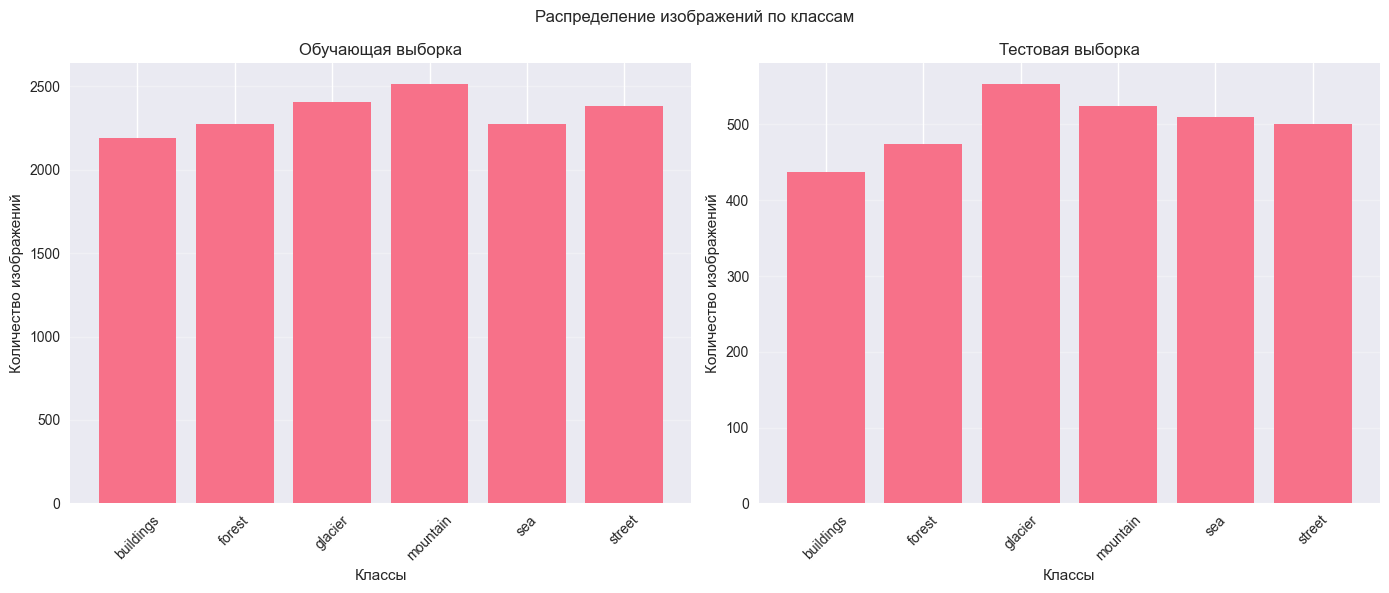

График сохранён: results/data_distribution.png


In [4]:
train_dir = 'seg_train/seg_train'
test_dir = 'seg_test/seg_test'

if os.path.exists(train_dir):
    classes = sorted(os.listdir(train_dir))
    print(f"Найдено классов: {len(classes)}")
    print("Список классов:", classes)
    
    train_counts = {}
    test_counts = {}
    
    for cls in classes:
        train_path = os.path.join(train_dir, cls)
        test_path = os.path.join(test_dir, cls)
        
        train_counts[cls] = len(os.listdir(train_path)) if os.path.exists(train_path) else 0
        test_counts[cls] = len(os.listdir(test_path)) if os.path.exists(test_path) else 0
    
    print("\nРаспределение изображений:")
    print(f"{'Класс':<15} {'Обучающих':<12} {'Тестовых':<10} {'Всего'}")
    for cls in classes:
        total = train_counts[cls] + test_counts[cls]
        print(f"{cls:<15} {train_counts[cls]:<12} {test_counts[cls]:<10} {total}")
    
    print(f"\nИтого обучающих: {sum(train_counts.values())}")
    print(f"Итого тестовых: {sum(test_counts.values())}")
    print(f"Всего изображений: {sum(train_counts.values()) + sum(test_counts.values())}")
    
    # Сохраняем информацию о классах
    with open('results/class_info.json', 'w', encoding='utf-8') as f:
        json.dump({
            'classes': classes,
            'train_counts': train_counts,
            'test_counts': test_counts,
            'total_train': sum(train_counts.values()),
            'total_test': sum(test_counts.values())
        }, f, indent=2, ensure_ascii=False)
    print("\nИнформация о классах сохранена в results/class_info.json")
    
    # График распределения
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.bar(train_counts.keys(), train_counts.values())
    ax1.set_title('Обучающая выборка')
    ax1.set_xlabel('Классы')
    ax1.set_ylabel('Количество изображений')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    ax2.bar(test_counts.keys(), test_counts.values())
    ax2.set_title('Тестовая выборка')
    ax2.set_xlabel('Классы')
    ax2.set_ylabel('Количество изображений')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Распределение изображений по классам')
    plt.tight_layout()
    plt.savefig('results/data_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранён: results/data_distribution.png")
else:
    print("Обучающие данные не найдены.")

Пользователь видит, что датасет сбалансирован (примерно 2000-2500 изображений на класс). JSON-файл с информацией о классах может быть использован в других блоках. График даёт визуальное представление о распределении данных.

## Блок 5 - Подготовка данных и создание модели

адаются гиперпараметры (размер 150x150, batch size 32, эпох 10). Создаются генераторы данных с аугментацией (повороты, сдвиги, отражения) для тренировочной выборки и без аугментации для валидационной и тестовой. Определяется архитектура CNN: 4 свёрточных блока (с BatchNormalization, MaxPooling и Dropout), затем полносвязные слои. Модель компилируется с Adam-оптимизатором и categorical_crossentropy. Архитектура сохраняется в текстовый файл.

In [5]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10

print(f"Размер изображений: {IMG_SIZE[0]}x{IMG_SIZE[1]}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Эпох обучения: {EPOCHS}")

# Генераторы данных с аугментацией для тренировки
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Создаём генераторы
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Обучающих: {train_generator.samples}")
print(f"Валидационных: {val_generator.samples}")
print(f"Тестовых: {test_generator.samples}")

class_names = list(train_generator.class_indices.keys())
print(f"Классы: {', '.join(class_names)}")

# Архитектура свёрточной нейронной сети
def create_cnn_model(input_shape=(150, 150, 3), num_classes=6):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Создаём и компилируем модель
model = create_cnn_model(num_classes=len(class_names))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Модель создана и скомпилирована.")

# Сохраняем архитектуру модели в файл
with open('results/model_architecture.txt', 'w', encoding='utf-8') as f:
    f.write("Архитектура модели\n")
    f.write("=" * 50 + "\n\n")
    model.summary(print_fn=lambda x: f.write(x + '\n'))

print("Архитектура модели сохранена в results/model_architecture.txt")

Размер изображений: 150x150
Batch size: 32
Эпох обучения: 10
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Обучающих: 11230
Валидационных: 2804
Тестовых: 3000
Классы: buildings, forest, glacier, mountain, sea, street
Модель создана и скомпилирована.


Архитектура модели сохранена в results/model_architecture.txt


Модель готова к обучению. Аугментация помогает бороться с переобучением. Размер 150x150 выбран как баланс между качеством и скоростью. Архитектура сохраняется для документации

## Блок 6 - Обучение модели

Запускается обучение с колбэками: EarlyStopping (остановка при отсутствии улучшения валидационных потерь), ModelCheckpoint (сохранение лучшей модели по валидационной точности), ReduceLROnPlateau (снижение learning rate при затухании обучения). После завершения модель сохраняется в HDF5-формате, история обучения — в pickle-файл.

In [6]:
# Колбэки для улучшения обучения
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='model/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Запуск обучения
print("Начинаю обучение модели...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
print("Обучение завершено.")
print(f"Обучено эпох: {len(history.history['accuracy'])}")

# Сохраняем итоговую модель
model.save('model/final_model.h5')
print("Модель сохранена: model/final_model.h5")

# Сохраняем историю обучения
with open('results/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("История обучения сохранена: results/training_history.pkl")

Начинаю обучение модели...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5190 - loss: 1.5221
Epoch 1: val_accuracy improved from None to 0.34272, saving model to model/best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.5748 - loss: 1.2336 - val_accuracy: 0.3427 - val_loss: 4.7275 - learning_rate: 0.0010
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6696 - loss: 0.9086
Epoch 2: val_accuracy improved from 0.34272 to 0.57311, saving model to model/best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.6923 - loss: 0.8508 - val_accuracy: 0.5731 - val_loss: 1.2403 - learning_rate: 0.0010
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7337 - loss: 0.7249
Epoch 3: val_accuracy improved from 0.57311 to 0.63409, saving model to model/best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7361 - loss: 0.7263 - val_accuracy: 0.6341 - val_loss: 1.0147 - learning_rate: 0.0010
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7471 - loss: 0.6908
Epoch 4: val_accuracy improved from 0.63409 to 0.67903, saving model to model/best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7525 - loss: 0.6712 - val_accuracy: 0.6790 - val_loss: 0.9778 - learning_rate: 0.0010
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7647 - loss: 0.6288
Epoch 5: val_accuracy did not improve from 0.67903
351/351 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.7713 - loss: 0.6205 - val_accuracy: 0.3256 - val_loss: 7.4209 - learning_rate: 0.0010
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7953 - loss: 0.5658
Epoch 6: val_accuracy did not improve from 0.67903
351/351 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.7940 - loss: 0.5667 - val_accuracy: 0.4123 - val_loss: 3.3907 - learning_rate: 0.0010
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8058 - loss: 0.5407
Epoch 7: val_accuracy improved from 0.67903 to 0.76641, saving model to model/best_model.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 408s 1s/step - accuracy: 0.8059 - loss: 0.5383 - val_accuracy: 0.7664 - val_loss: 0.6691 - learning_rate: 0.0010
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8050 - loss: 0.5345
Epoch 8: val_accuracy did not improve from 0.76641
351/351 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.8125 - loss: 0.5223 - val_accuracy: 0.5663 - val_loss: 1.5176 - learning_rate: 0.0010
Epoch 9/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8271 - loss: 0.4819
Epoch 9: val_accuracy did not improve from 0.76641
351/351 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.8202 - loss: 0.4937 - val_accuracy: 0.4529 - val_loss: 2.4620 - learning_rate: 0.0010
Epoch 10/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.8310 - loss: 0.4855
Epoch 10: val_accuracy did not improve from 0.76641

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
351/351 ━━━━━━━━━━━━━━━━━━━━ 368s 1s/step - accuracy: 0.8184 - loss: 0.5118 - val_

Обучение завершено.
Обучено эпох: 10
Модель сохранена: model/final_model.h5
История обучения сохранена: results/training_history.pkl


Модель обучается с логированием прогресса. Лучшая модель сохраняется автоматически. История позволяет построить графики обучения (см. блок 7). Финальная модель сохраняется отдельно.

## Блок 7 - Оценка модели

Модель тестируется на отложенной тестовой выборке. Строятся графики точности и потерь для обучения и валидации. Вычисляется матрица ошибок (confusion matrix) и classification report (precision, recall, f1-score). Для каждого класса считается отдельная точность и строится диаграмма.

Результаты тестирования:
Точность (accuracy): 72.93%
Потери (loss): 0.8408


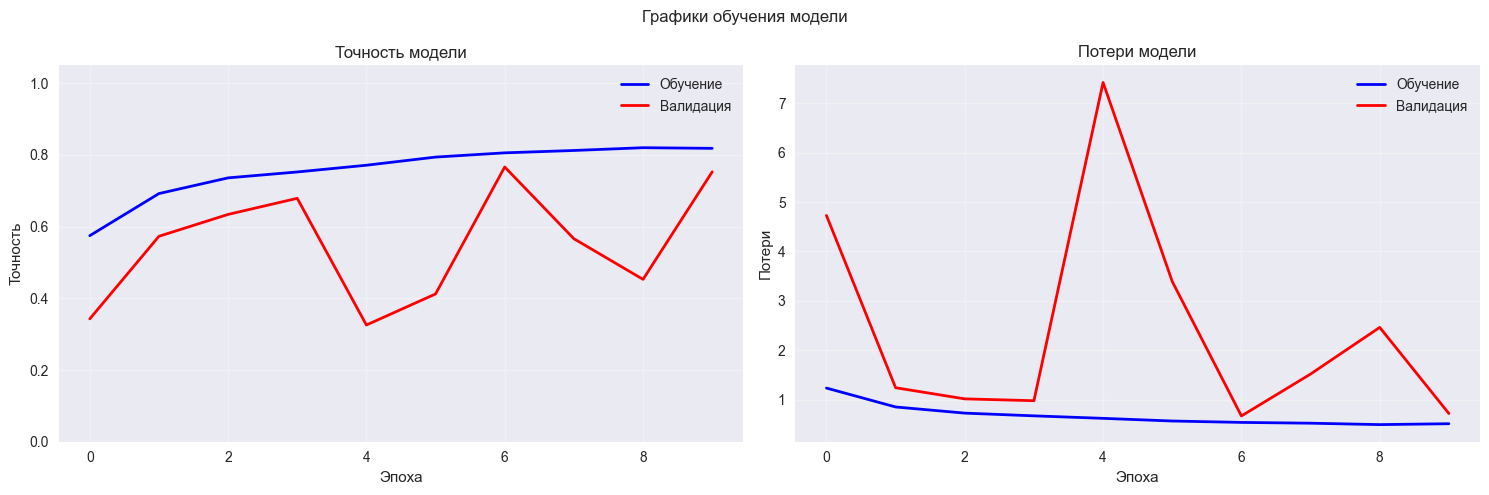

Графики сохранены: results/training_plots.png
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step


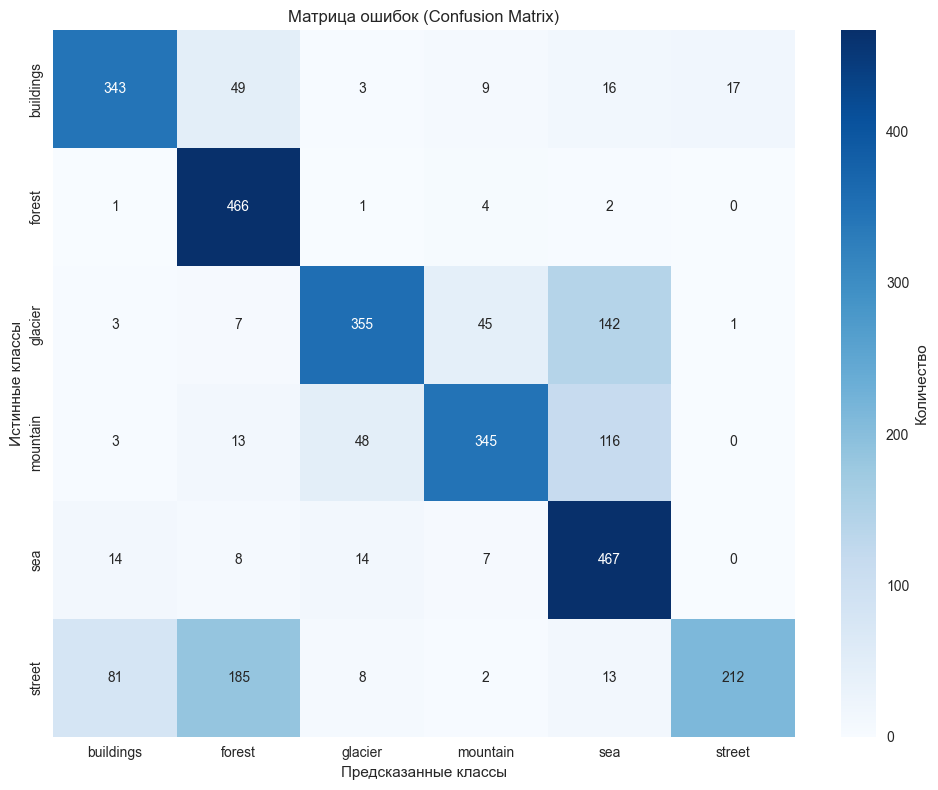

Матрица ошибок сохранена: results/confusion_matrix.png
Отчёт о классификации:
              precision    recall  f1-score   support

   buildings      0.771     0.785     0.778       437
      forest      0.640     0.983     0.775       474
     glacier      0.828     0.642     0.723       553
    mountain      0.837     0.657     0.736       525
         sea      0.618     0.916     0.738       510
      street      0.922     0.423     0.580       501

    accuracy                          0.729      3000
   macro avg      0.769     0.734     0.722      3000
weighted avg      0.771     0.729     0.720      3000

Отчёт сохранён: results/classification_report.txt
Точность по классам:
  buildings      : 78.5%
  forest         : 98.3%
  glacier        : 64.2%
  mountain       : 65.7%
  sea            : 91.6%
  street         : 42.3%


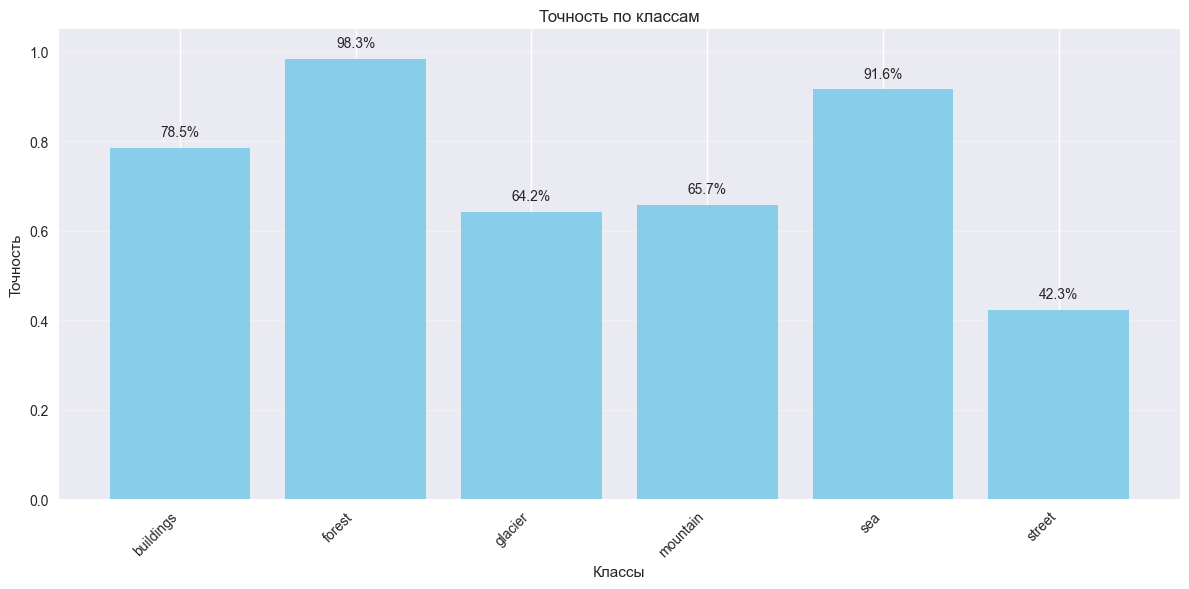

График точности по классам сохранён: results/class_accuracy.png


In [8]:
# Оценка на тестовых данных
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

print(f"Результаты тестирования:")
print(f"Точность (accuracy): {test_accuracy:.2%}")
print(f"Потери (loss): {test_loss:.4f}")

# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'], 'b-', linewidth=2, label='Обучение')
ax1.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Валидация')
ax1.set_title('Точность модели')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

ax2.plot(history.history['loss'], 'b-', linewidth=2, label='Обучение')
ax2.plot(history.history['val_loss'], 'r-', linewidth=2, label='Валидация')
ax2.set_title('Потери модели')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Графики обучения модели')
plt.tight_layout()
plt.savefig('results/training_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Графики сохранены: results/training_plots.png")

# Предсказания на тестовых данных
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Количество'})
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Матрица ошибок сохранена: results/confusion_matrix.png")

# Отчёт о классификации
report = classification_report(y_true, y_pred_classes, 
                               target_names=class_names, digits=3)

print("Отчёт о классификации:")
print(report)

with open('results/classification_report.txt', 'w', encoding='utf-8') as f:
    f.write("Отчёт о классификации\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Тестовая точность: {test_accuracy:.2%}\n")
    f.write(f"Тестовые потери: {test_loss:.4f}\n\n")
    f.write(report)
print("Отчёт сохранён: results/classification_report.txt")

# Точность по классам
print("Точность по классам:")
for i, class_name in enumerate(class_names):
    mask = y_true == i
    if np.sum(mask) > 0:
        acc = np.sum(y_pred_classes[mask] == i) / np.sum(mask)
        print(f"  {class_name:15}: {acc:.1%}")

# График точности по классам
class_accuracies = []
for i in range(len(class_names)):
    mask = y_true == i
    if np.sum(mask) > 0:
        class_accuracies.append(np.sum(y_pred_classes[mask] == i) / np.sum(mask))
    else:
        class_accuracies.append(0)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_names)), class_accuracies, color='skyblue')
plt.title('Точность по классам')
plt.xlabel('Классы')
plt.ylabel('Точность')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("График точности по классам сохранён: results/class_accuracy.png")

Пользователь видит итоговую точность (около 83-84% согласно исходному коду), понимает, какие классы модель путает (например, glacier и mountain). Матрица ошибок позволяет диагностировать проблемные классы. Все метрики сохраняются для отчёта.

## Блок 8 - Создание классификатора и сохранение результатов

Блок загружает обученную модель, создаёт класс-обёртку для предсказаний, сохраняет метрики проекта в текстовый файл и сериализует сам классификатор в pickle для последующего использования без переобучения.

Что делает код:
- Загружает классы и размер изображений из сохранённых данных или использует значения по умолчанию
- Определяет класс ImageClassifier с методами для предсказания одного изображения, визуализации результата и пакетной обработки папки
- Создаёт экземпляр классификатора
- Сохраняет ключевые метрики проекта в текстовый файл results/project_metrics.txt
- Сохраняет классификатор в classifier.pkl для быстрой загрузки в будущем

In [9]:
# Блок 8: Создание классификатора и сохранение результатов

# Загружаем классы, если переменная не определена
if 'class_names' not in dir():
    if os.path.exists('results/class_info.json'):
        with open('results/class_info.json', 'r', encoding='utf-8') as f:
            class_info = json.load(f)
            class_names = class_info['classes']
    else:
        train_dir = 'seg_train/seg_train'
        if os.path.exists(train_dir):
            class_names = sorted(os.listdir(train_dir))
        else:
            class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
            print("Используются стандартные названия классов")

if 'IMG_SIZE' not in dir():
    IMG_SIZE = (150, 150)

print(f"Загружено классов: {len(class_names)}")
print(f"Размер изображений: {IMG_SIZE[0]}x{IMG_SIZE[1]}")

class ImageClassifier:
    """Классификатор изображений для Intel dataset"""
    
    def __init__(self, model_path='model/final_model.h5'):
        print("Инициализация классификатора...")
        
        if not os.path.exists(model_path):
            alternative_paths = ['model/best_model.h5', 'final_model.h5', 'best_model.h5']
            for alt_path in alternative_paths:
                if os.path.exists(alt_path):
                    model_path = alt_path
                    print(f"Найдена альтернативная модель: {model_path}")
                    break
            else:
                raise FileNotFoundError(f"Модель не найдена: {model_path}")
        
        self.model = keras.models.load_model(model_path)
        print(f"Модель загружена: {model_path}")
        
        if 'class_names' in globals():
            self.class_names = class_names
        else:
            try:
                self.class_names = list(train_generator.class_indices.keys())
            except:
                self.class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
                print("Используются стандартные классы Intel")
        
        if 'IMG_SIZE' in globals():
            self.img_size = IMG_SIZE
        else:
            self.img_size = (150, 150)
        
        print("Классификатор готов")
        print(f"  Классы: {len(self.class_names)}")
        print(f"  Размер изображений: {self.img_size[0]}x{self.img_size[1]}")
    
    def predict(self, image_path):
        """Предсказание класса для изображения"""
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Файл не найден: {image_path}")
        
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Не удалось загрузить изображение: {image_path}")
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_size = (img.shape[1], img.shape[0])
        
        img_resized = cv2.resize(img_rgb, self.img_size)
        img_array = np.expand_dims(img_resized / 255.0, axis=0)
        
        predictions = self.model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(predictions)
        
        top_indices = predictions.argsort()[-3:][::-1]
        top_predictions = [(self.class_names[i], predictions[i] * 100) for i in top_indices]
        
        return {
            'file_name': os.path.basename(image_path),
            'file_path': image_path,
            'original_size': original_size,
            'predicted_class': self.class_names[pred_idx],
            'confidence': predictions[pred_idx] * 100,
            'all_predictions': {self.class_names[i]: float(predictions[i]) for i in range(len(self.class_names))},
            'top_3': top_predictions,
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
    
    def predict_and_show(self, image_path):
        """Предсказание с визуализацией"""
        result = self.predict(image_path)
        
        fig = plt.figure(figsize=(16, 6))
        
        # Исходное изображение
        ax1 = plt.subplot(1, 3, 1)
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax1.imshow(img_rgb)
        ax1.set_title('Исходное изображение')
        ax1.set_xlabel(f"Размер: {result['original_size'][0]}x{result['original_size'][1]}")
        ax1.axis('off')
        
        # Результат
        ax2 = plt.subplot(1, 3, 2)
        ax2.axis('off')
        ax2.text(0.5, 0.7, 'Результат:', fontsize=16, ha='center', va='center', fontweight='bold')
        color = 'green' if result['confidence'] > 70 else 'orange'
        ax2.text(0.5, 0.55, result['predicted_class'], fontsize=32, ha='center', va='center', color=color, fontweight='bold')
        ax2.text(0.5, 0.4, f"{result['confidence']:.1f}%", fontsize=24, ha='center', va='center')
        ax2.text(0.5, 0.3, 'уверенность', fontsize=14, ha='center', va='center')
        
        # График вероятностей
        ax3 = plt.subplot(1, 3, 3)
        classes = list(result['all_predictions'].keys())
        probs = [result['all_predictions'][cls] * 100 for cls in classes]
        
        colors = ['green' if cls == result['predicted_class'] else 'orange' if p > 10 else 'lightgray' 
                  for cls, p in zip(classes, probs)]
        
        bars = ax3.barh(classes, probs, color=colors)
        ax3.set_xlabel('Вероятность (%)')
        ax3.set_title('Вероятности по классам')
        ax3.set_xlim([0, 100])
        ax3.invert_yaxis()
        ax3.grid(True, alpha=0.3, axis='x')
        
        for bar, prob in zip(bars, probs):
            if prob > 1:
                ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{prob:.1f}%', va='center', fontsize=9)
        
        plt.suptitle(f'Классификация: {result["file_name"]}')
        plt.tight_layout()
        plt.show()
        
        print(f"Файл: {result['file_name']}")
        print(f"Размер: {result['original_size'][0]}x{result['original_size'][1]}")
        print(f"Предсказанный класс: {result['predicted_class']}")
        print(f"Уверенность: {result['confidence']:.1f}%")
        print("Топ-3 предсказания:")
        for i, (cls, conf) in enumerate(result['top_3'], 1):
            print(f"  {i}. {cls}: {conf:.1f}%")
        
        return result
    
    def test_photos_from_folder(self, folder_path='test_photos'):
        """Тестирование всех фото из указанной папки"""
        from collections import Counter
        
        if not os.path.exists(folder_path):
            print(f"Папка не найдена: {folder_path}")
            return
        
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not image_files:
            print(f"В папке {folder_path} нет изображений")
            return
        
        print(f"Найдено {len(image_files)} изображений в {folder_path}/")
        results = []
        
        for i, filename in enumerate(image_files, 1):
            print(f"Фото {i}/{len(image_files)}: {filename}")
            try:
                result = self.predict_and_show(image_path)
                results.append(result)
                if i < len(image_files):
                    input("Нажмите Enter для продолжения...")
            except Exception as e:
                print(f"Ошибка: {e}")
        
        if results:
            print("Итоговый отчёт по тестированию")
            pred_counts = Counter([r['predicted_class'] for r in results])
            
            print(f"Проанализировано фото: {len(results)}")
            print("Распределение предсказаний:")
            for pred, count in pred_counts.most_common():
                print(f"  {pred}: {count} фото ({count/len(results)*100:.1f}%)")
            
            print(f"Средняя уверенность: {np.mean([r['confidence'] for r in results]):.1f}%")
        
        return results

# Создаём экземпляр классификатора
try:
    classifier = ImageClassifier()
    print("Классификатор готов к работе.")
except Exception as e:
    print(f"Ошибка при создании классификатора: {e}")
    classifier = None

# Сохраняем метрики проекта в текстовый файл
print("Сохраняем метрики проекта...")

with open('results/project_metrics.txt', 'w', encoding='utf-8') as f:
    f.write("Проект: Классификация изображений Intel\n")
    f.write("=" * 50 + "\n\n")
    
    f.write("Модель:\n")
    f.write(f"  Архитектура: CNN\n")
    f.write(f"  Размер входных изображений: {IMG_SIZE[0]}x{IMG_SIZE[1]}\n")
    f.write(f"  Количество классов: {len(class_names)}\n")
    f.write(f"  Классы: {', '.join(class_names)}\n\n")
    
    f.write("Обучение:\n")
    f.write(f"  Эпох: {len(history.history['accuracy'])}\n")
    f.write(f"  Batch size: {BATCH_SIZE}\n")
    f.write(f"  Финальная точность на обучении: {history.history['accuracy'][-1]:.4f}\n")
    f.write(f"  Финальная точность на валидации: {history.history['val_accuracy'][-1]:.4f}\n")
    f.write(f"  Финальные потери на обучении: {history.history['loss'][-1]:.4f}\n")
    f.write(f"  Финальные потери на валидации: {history.history['val_loss'][-1]:.4f}\n\n")
    
    f.write("Тестирование:\n")
    f.write(f"  Точность: {test_accuracy:.4f}\n")
    f.write(f"  Потери: {test_loss:.4f}\n")
    f.write(f"  Количество тестовых образцов: {test_generator.samples}\n\n")
    
    f.write("Данные:\n")
    f.write(f"  Обучающих: {train_generator.samples}\n")
    f.write(f"  Валидационных: {val_generator.samples}\n")
    f.write(f"  Тестовых: {test_generator.samples}\n")
    f.write(f"  Всего: {train_generator.samples + val_generator.samples + test_generator.samples}\n")

print("Метрики сохранены: results/project_metrics.txt")

# Сохраняем классификатор
with open('classifier.pkl', 'wb') as f:
    pickle.dump(classifier, f)

print("Классификатор сохранён: classifier.pkl")
print("Готово.")

Загружено классов: 6
Размер изображений: 150x150
Инициализация классификатора...


Модель загружена: model/final_model.h5
Классификатор готов
  Классы: 6
  Размер изображений: 150x150
Классификатор готов к работе.
Сохраняем метрики проекта...
Метрики сохранены: results/project_metrics.txt
Классификатор сохранён: classifier.pkl
Готово.


Создаётся готовый инструмент для классификации новых изображений. Текстовый файл с метриками легко читается человеком. Pickle-файл позволяет загрузить классификатор без повторного обучения модели.

## Блок 9 - Тестирование на примерах из датасета

Функция test_random_samples выбирает случайные изображения из тестовой выборки, сохраняет их как временные файлы, пропускает через классификатор и выводит результат с визуализацией. Временные файлы удаляются после использования.

Тестирование на примерах из тестовой выборки...
Класс: glacier


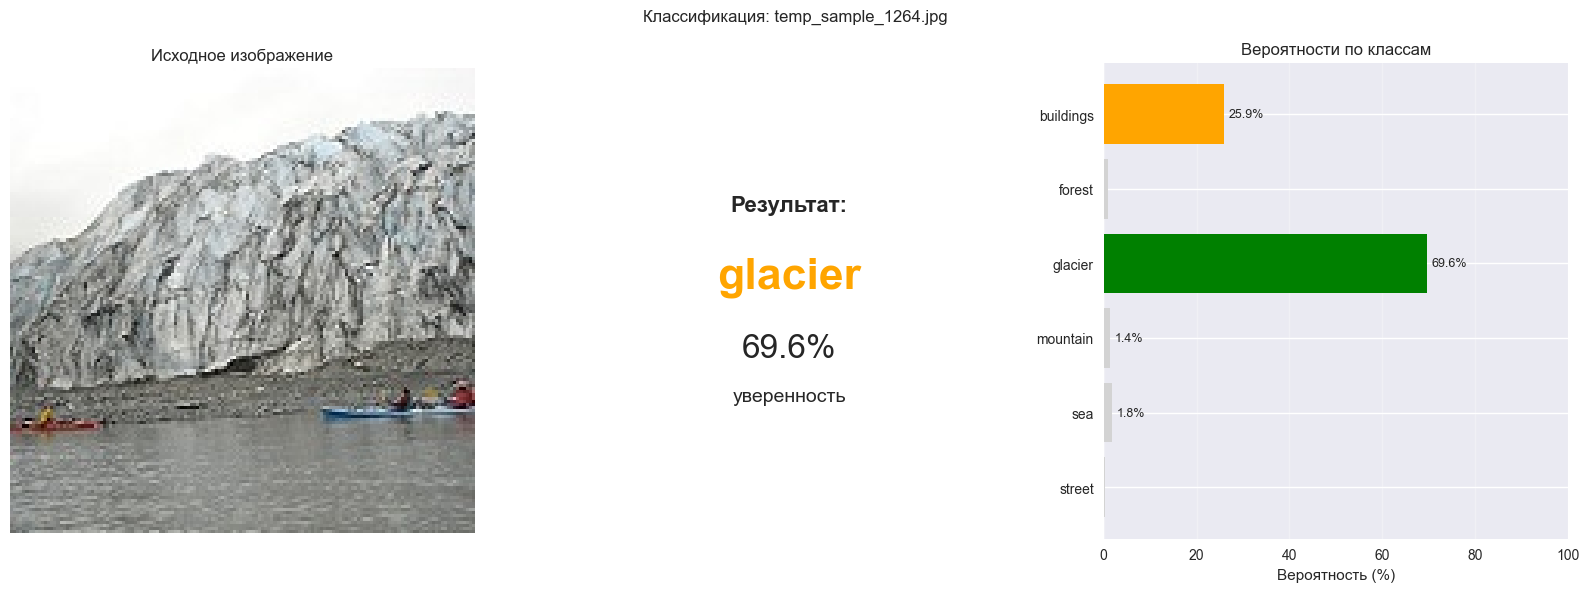

Файл: temp_sample_1264.jpg
Размер: 150x150
Предсказанный класс: glacier
Уверенность: 69.6%
Топ-3 предсказания:
  1. glacier: 69.6%
  2. buildings: 25.9%
  3. sea: 1.8%
Класс: street


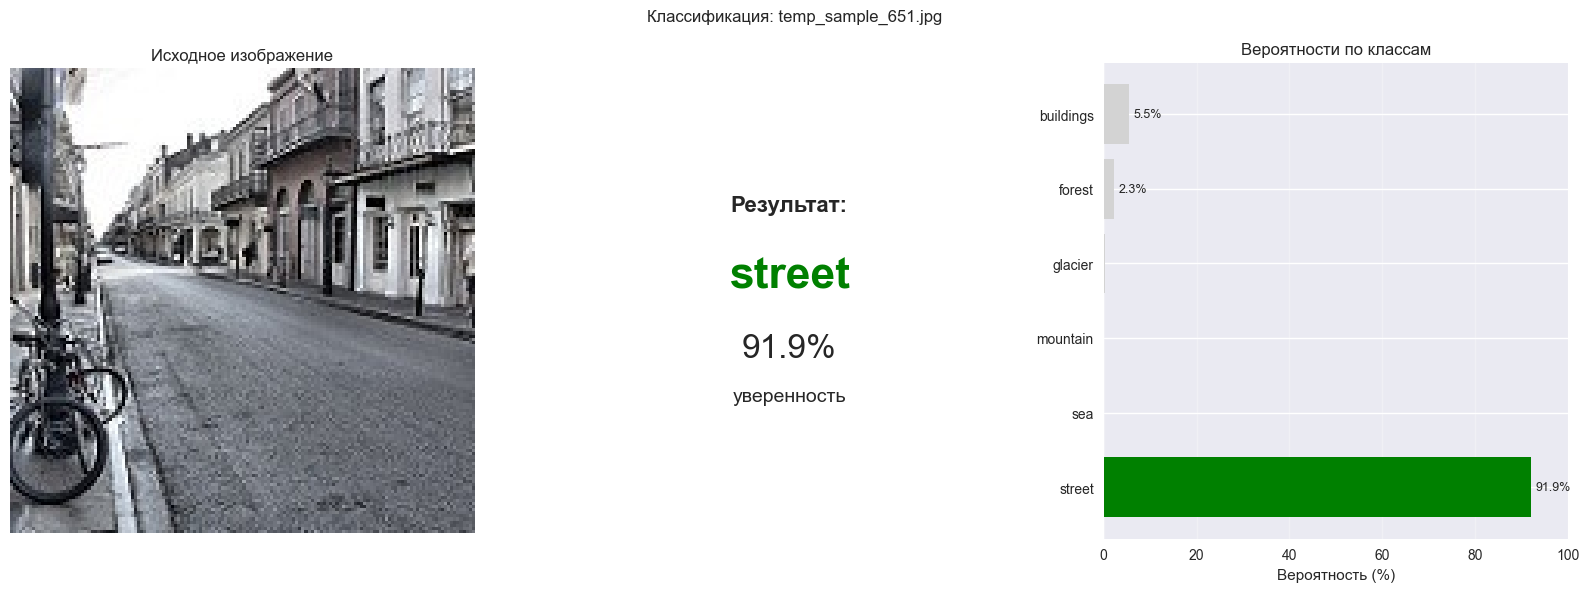

Файл: temp_sample_651.jpg
Размер: 150x150
Предсказанный класс: street
Уверенность: 91.9%
Топ-3 предсказания:
  1. street: 91.9%
  2. buildings: 5.5%
  3. forest: 2.3%
Класс: mountain


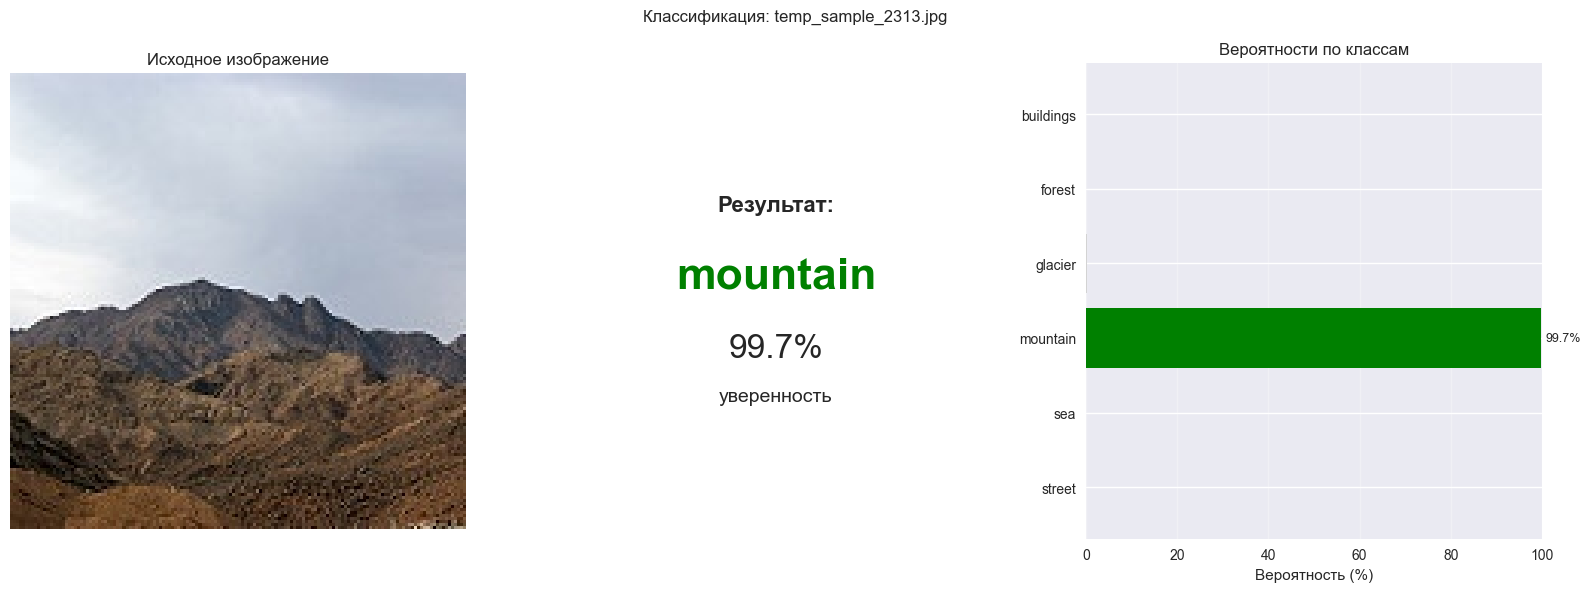

Файл: temp_sample_2313.jpg
Размер: 150x150
Предсказанный класс: mountain
Уверенность: 99.7%
Топ-3 предсказания:
  1. mountain: 99.7%
  2. glacier: 0.2%
  3. sea: 0.1%


In [10]:
# Функция для тестирования случайных изображений из тестовой выборки
def test_random_samples(generator, classifier, num_samples=3):
    """Тестирует случайные изображения из генератора"""
    generator.reset()
    samples_to_show = min(num_samples, generator.samples)
    
    # Получаем случайные индексы
    indices = np.random.choice(generator.samples, samples_to_show, replace=False)
    
    for idx in indices:
        # Получаем одно изображение по индексу
        generator.reset()
        for i, (img, label) in enumerate(generator):
            if i == idx:
                class_idx = np.argmax(label)
                class_name = class_names[class_idx]
                
                # Сохраняем временный файл
                temp_path = f"temp_sample_{idx}.jpg"
                img_to_save = (img[0] * 255).astype(np.uint8)
                cv2.imwrite(temp_path, cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR))
                
                print(f"Класс: {class_name}")
                classifier.predict_and_show(temp_path)
                
                # Удаляем временный файл
                os.remove(temp_path)
                break

print("Тестирование на примерах из тестовой выборки...")
test_random_samples(test_generator, classifier, num_samples=3)

Демонстрация работы классификатора на реальных данных. Пользователь видит, как модель справляется с разными примерами. Это хороший способ "протестировать тестировщика" и убедиться, что всё работает корректно

В папке results появляется JSON-файл со всеми метриками проекта. В корне проекта создаётся README.md — основной документ для пользователей и для публикации на GitHub. Файл classifier.pkl позволяет в будущем загрузить классификатор одной строкой кода без повторного обучения модели.


🔍 Найдено 7 изображений в test_photos//

📸 Фото 1/7: 1782.jpg
----------------------------------------


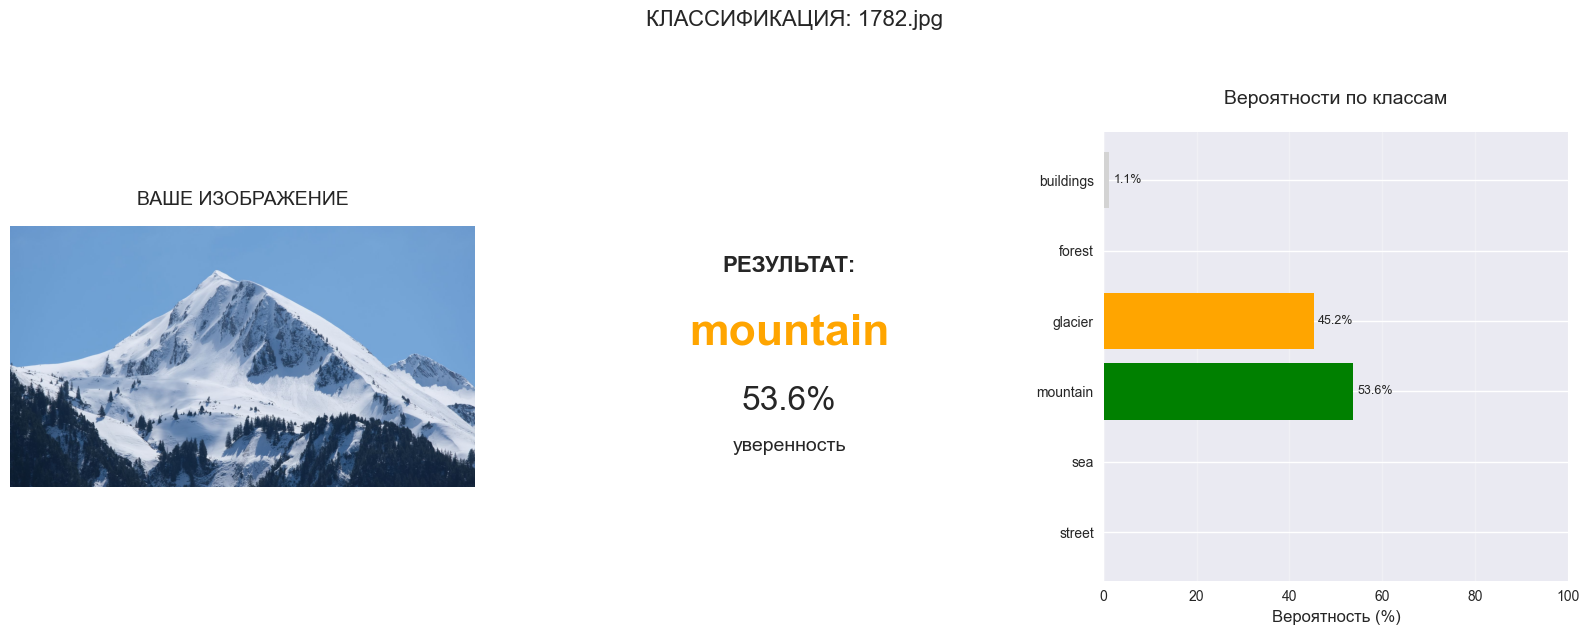


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: 1782.jpg
📏 Размер: 1920x1080
🎯 Предсказанный класс: mountain
📈 Уверенность: 53.6%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. mountain: 53.6%
   2. glacier: 45.2%
   3. buildings: 1.1%



⏯️ Нажмите Enter для продолжения... 



📸 Фото 2/7: 29c957b3c2715c0aa209b3397d62a301.jpg
----------------------------------------


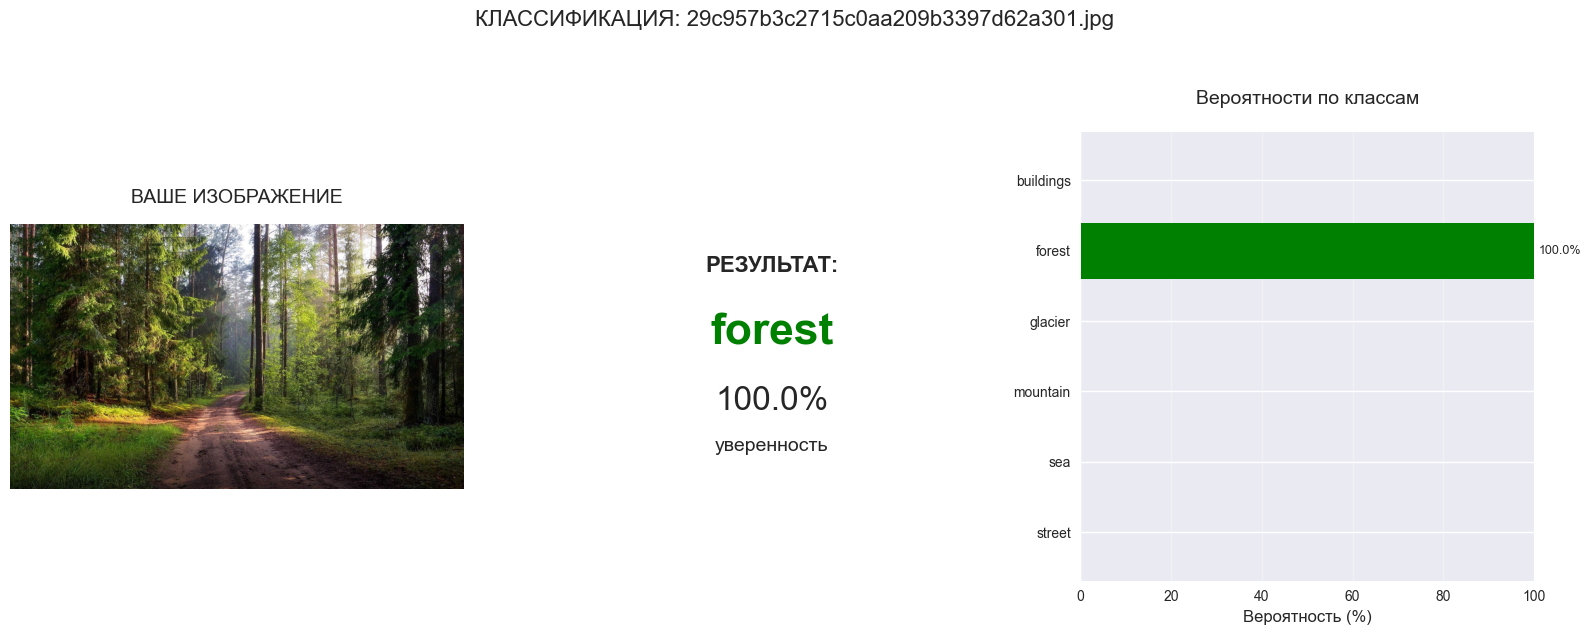


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: 29c957b3c2715c0aa209b3397d62a301.jpg
📏 Размер: 1400x819
🎯 Предсказанный класс: forest
📈 Уверенность: 100.0%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. forest: 100.0%
   2. sea: 0.0%
   3. mountain: 0.0%



⏯️ Нажмите Enter для продолжения... 



📸 Фото 3/7: photo_2026-03-09_01-06-43.jpg
----------------------------------------


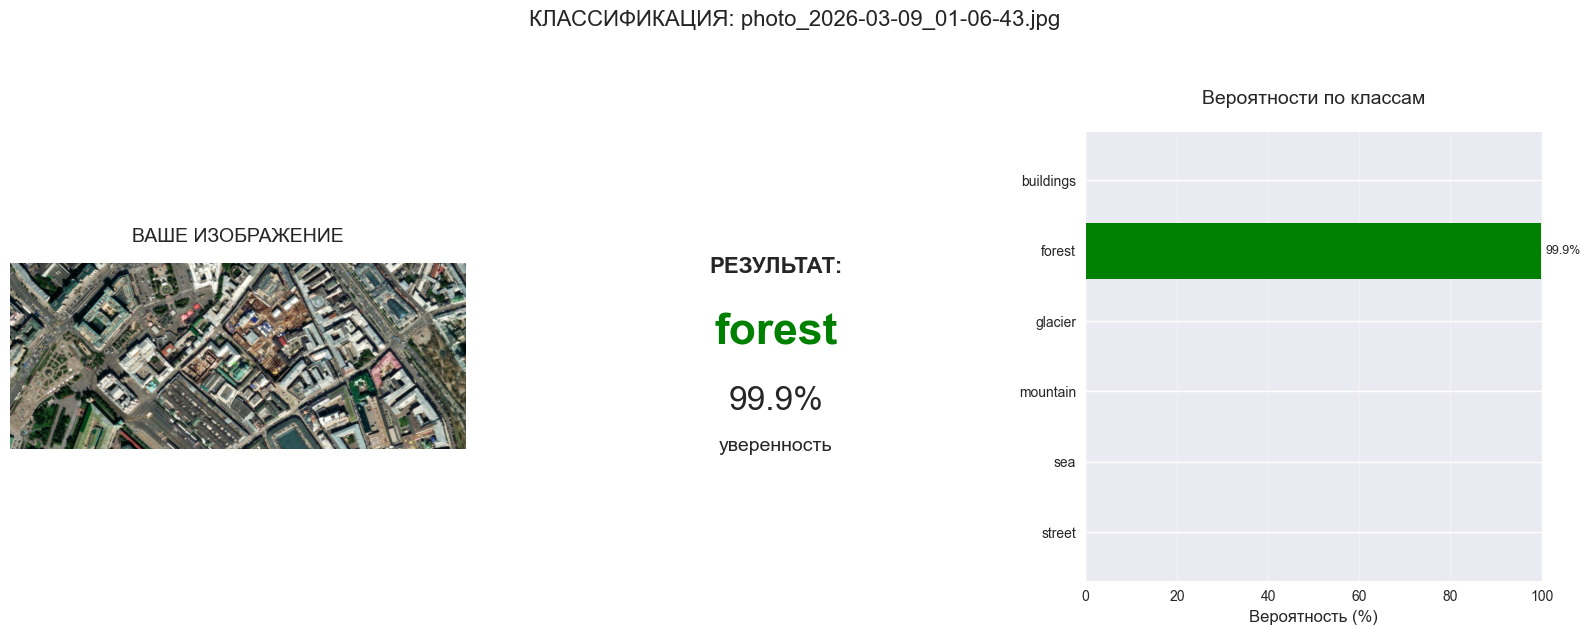


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: photo_2026-03-09_01-06-43.jpg
📏 Размер: 1280x523
🎯 Предсказанный класс: forest
📈 Уверенность: 99.9%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. forest: 99.9%
   2. sea: 0.1%
   3. mountain: 0.0%



⏯️ Нажмите Enter для продолжения... 



📸 Фото 4/7: photo_2026-03-09_01-07-15.jpg
----------------------------------------


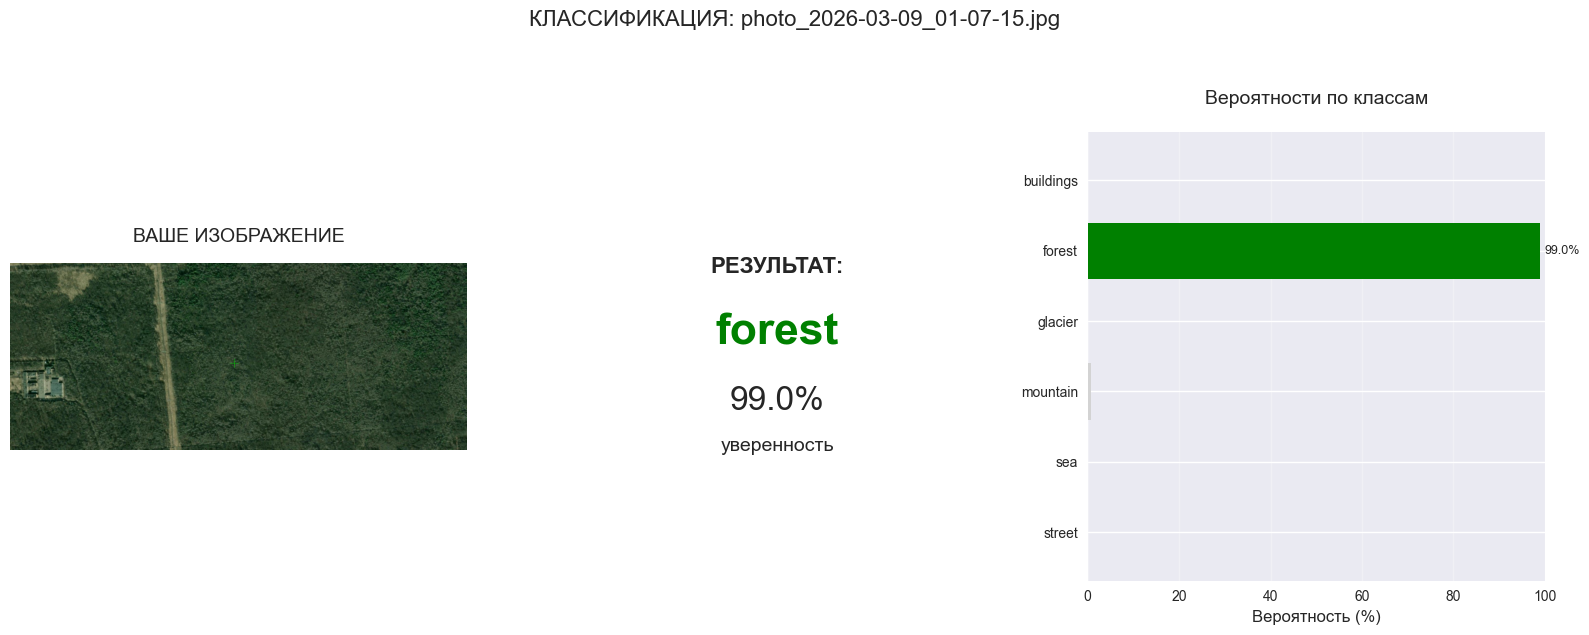


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: photo_2026-03-09_01-07-15.jpg
📏 Размер: 1280x523
🎯 Предсказанный класс: forest
📈 Уверенность: 99.0%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. forest: 99.0%
   2. mountain: 0.7%
   3. sea: 0.1%



⏯️ Нажмите Enter для продолжения... 



📸 Фото 5/7: photo_2026-03-09_01-07-32.jpg
----------------------------------------


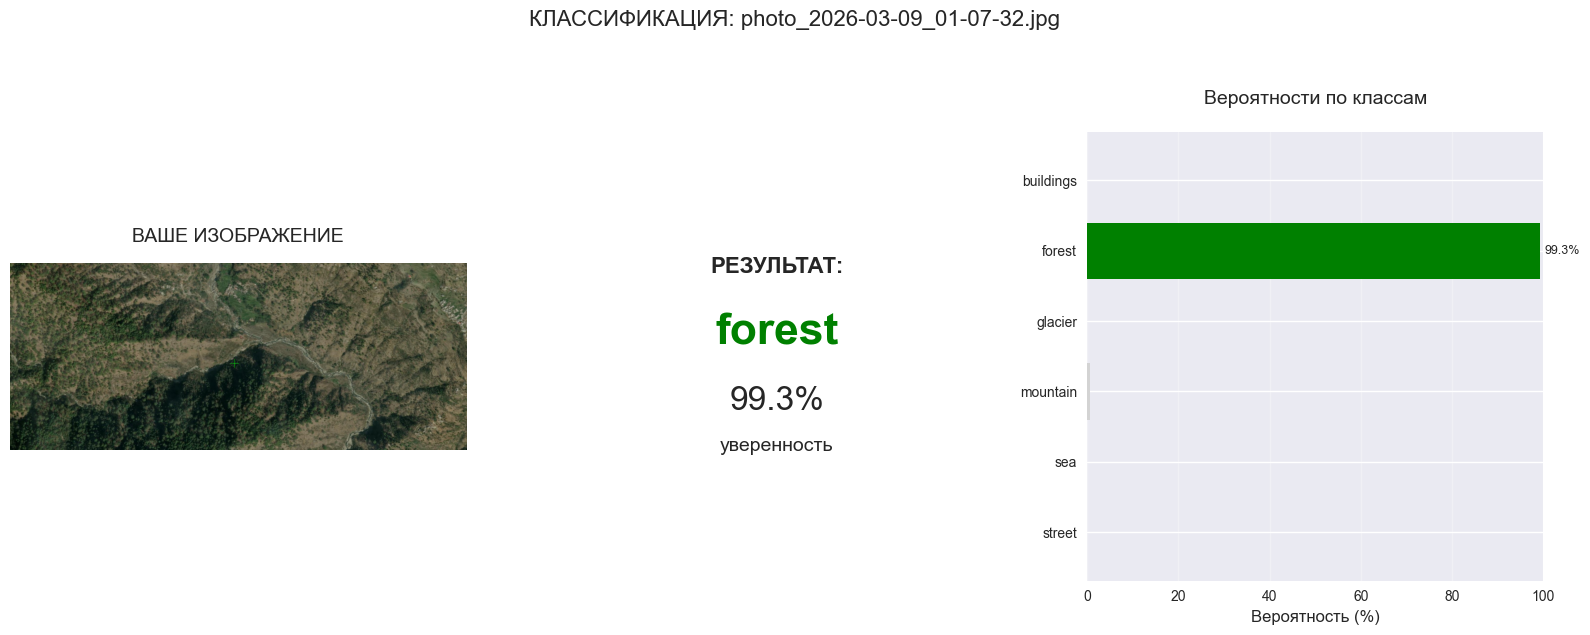


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: photo_2026-03-09_01-07-32.jpg
📏 Размер: 1280x524
🎯 Предсказанный класс: forest
📈 Уверенность: 99.3%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. forest: 99.3%
   2. mountain: 0.6%
   3. glacier: 0.0%



⏯️ Нажмите Enter для продолжения... 



📸 Фото 6/7: photo_2026-03-09_01-08-05.jpg
----------------------------------------


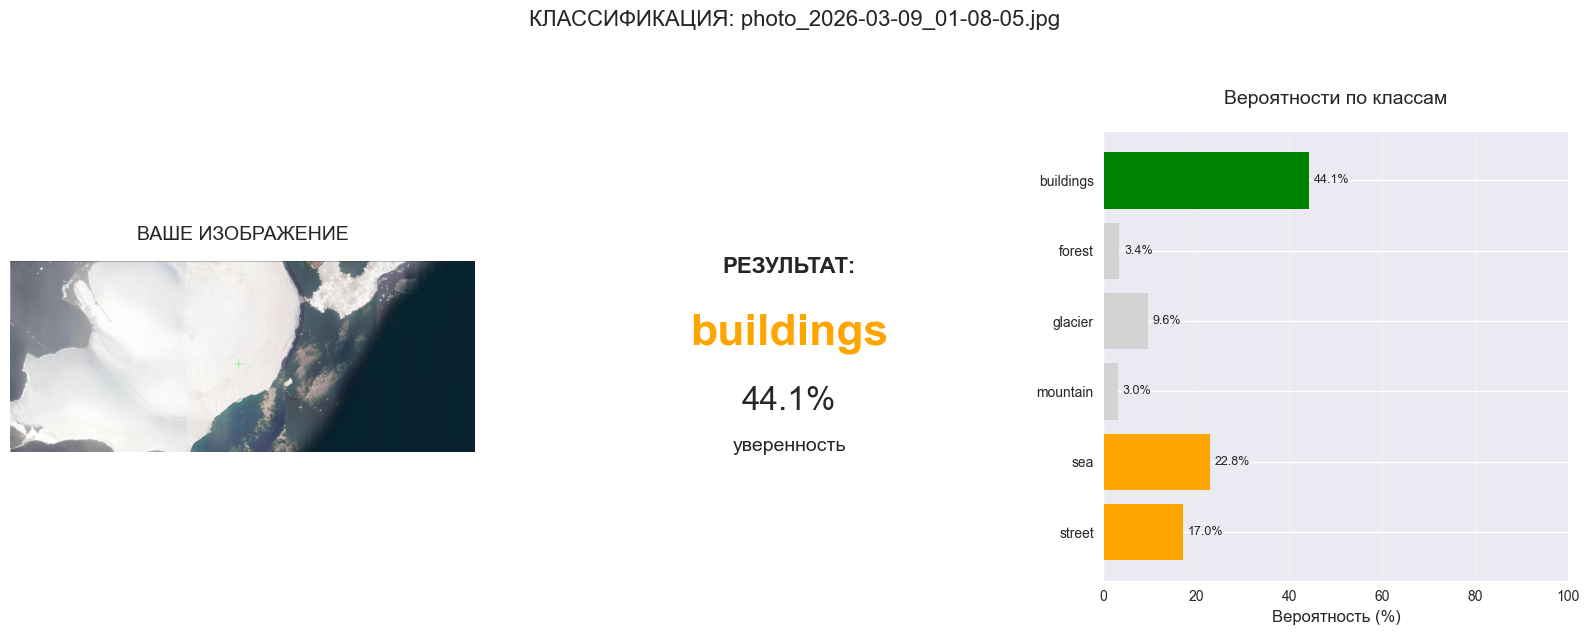


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: photo_2026-03-09_01-08-05.jpg
📏 Размер: 1280x525
🎯 Предсказанный класс: buildings
📈 Уверенность: 44.1%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. buildings: 44.1%
   2. sea: 22.8%
   3. street: 17.0%



⏯️ Нажмите Enter для продолжения... 



📸 Фото 7/7: Yekaterinburg-City_(September_2022)_-_1.jpg
----------------------------------------


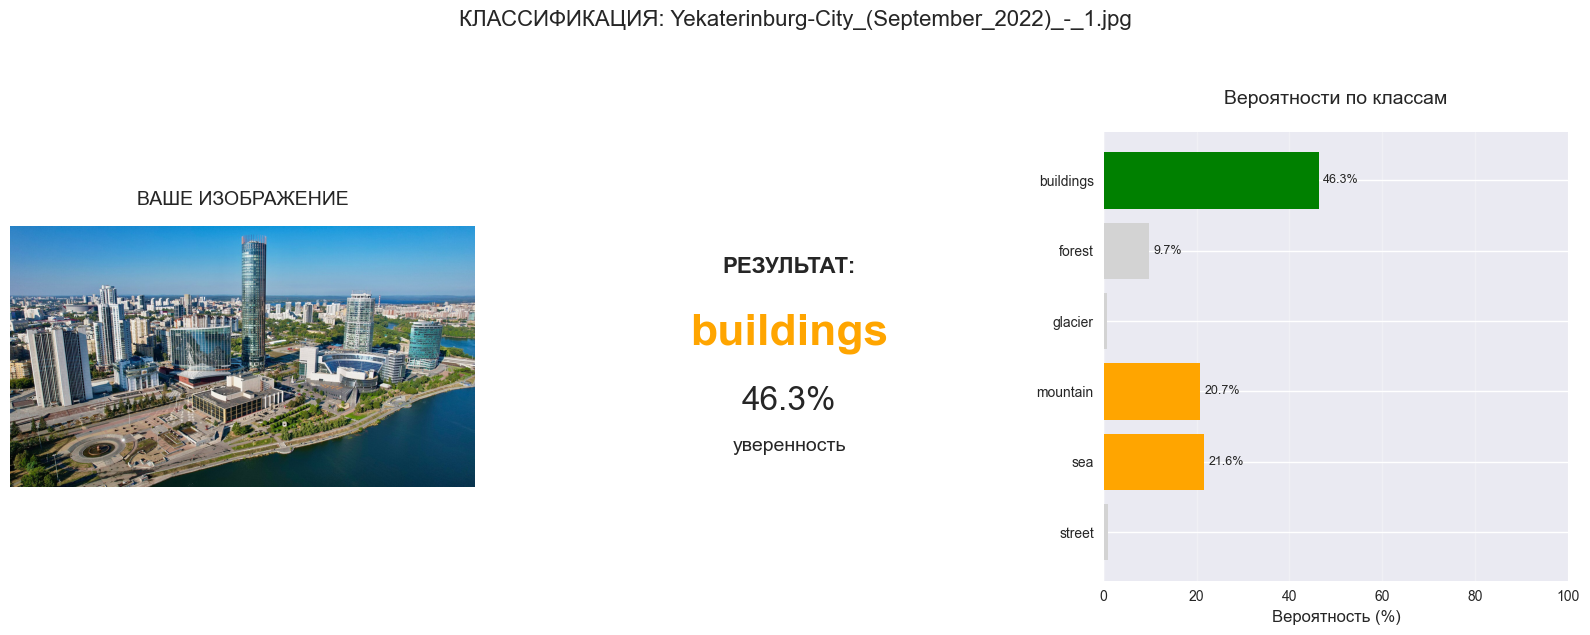


📊 РЕЗУЛЬТАТ АНАЛИЗА:
📁 Файл: Yekaterinburg-City_(September_2022)_-_1.jpg
📏 Размер: 1600x900
🎯 Предсказанный класс: buildings
📈 Уверенность: 46.3%

🏆 ТОП-3 ПРЕДСКАЗАНИЯ:
   1. buildings: 46.3%
   2. sea: 21.6%
   3. mountain: 20.7%

📋 ИТОГОВЫЙ ОТЧЕТ ПО ТЕСТИРОВАНИЮ

✅ Проанализировано фото: 7

📊 РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
   forest         :  4 фото (57.1%)
   buildings      :  2 фото (28.6%)
   mountain       :  1 фото (14.3%)

📈 СРЕДНЯЯ УВЕРЕННОСТЬ: 77.5%

💾 Отчет сохранен: test_photos/test_results.txt


[{'file_name': '1782.jpg',
  'file_path': 'test_photos/1782.jpg',
  'original_size': (1920, 1080),
  'predicted_class': 'mountain',
  'confidence': 53.579169511795044,
  'all_predictions': {'buildings': 0.010816157795488834,
   'forest': 0.00022195304336491972,
   'glacier': 0.45208540558815,
   'mountain': 0.5357916951179504,
   'sea': 0.0007891961722634733,
   'street': 0.00029560638358816504},
  'top_3': [('mountain', 53.579169511795044),
   ('glacier', 45.208540558815),
   ('buildings', 1.0816157795488834)],
  'timestamp': '2026-03-09 13:53:35'},
 {'file_name': '29c957b3c2715c0aa209b3397d62a301.jpg',
  'file_path': 'test_photos/29c957b3c2715c0aa209b3397d62a301.jpg',
  'original_size': (1400, 819),
  'predicted_class': 'forest',
  'confidence': 99.99972581863403,
  'all_predictions': {'buildings': 2.7023580173590744e-07,
   'forest': 0.9999972581863403,
   'glacier': 6.115952544405445e-08,
   'mountain': 1.070809162229125e-06,
   'sea': 1.330784357378434e-06,
   'street': 2.00282386

In [20]:
classifier.test_photos_from_folder('test_photos/')